# CVRP VQE Simulator

Read a CVRP `.vrp` instance from the local `cvrp` folder, build the CVRP formulation, and convert it into a QUBO before moving on to VQE-specific work.


In [10]:
from pathlib import Path
import math
import re

import numpy as np
import matplotlib.pyplot as plt

from docplex.mp.model import Model
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo


## Locate CVRP Instances

In [11]:
def find_cvrp_dir():
    candidates = [
        Path("cvrp"),
        Path("individual") / "cvrp",
        Path.cwd() / "cvrp",
        Path.cwd() / "individual" / "cvrp",
    ]
    for candidate in candidates:
        if candidate.exists() and any(candidate.glob("*.vrp")):
            return candidate
    raise FileNotFoundError("Could not find a cvrp folder containing .vrp files.")


CVRP_DIR = find_cvrp_dir()
available_instances = sorted(CVRP_DIR.glob("*.vrp"))

print(f"CVRP directory: {CVRP_DIR.resolve()}")
print("Available instances:")
for path in available_instances:
    print(f"- {path.name}")


CVRP directory: /Users/monitsharma/SMU-Quantum-Repos/autoqresearch/individual/cvrp
Available instances:
- XSH-n20-k4-01.vrp
- XSH-n20-k4-02.vrp
- XSH-n20-k4-03.vrp
- XSH-n20-k4-04.vrp
- XSH-n20-k4-05.vrp
- XSH-n20-k4-06.vrp
- XSH-n20-k4-07.vrp
- XSH-n20-k4-08.vrp
- XSH-n20-k4-09.vrp
- XSH-n20-k4-10.vrp


## VRP Reader

In [12]:
def read_cvrp_instance(file_path):
    file_path = Path(file_path)
    metadata = {}
    coords = {}
    demands = {}
    depots = []
    section = None

    for raw_line in file_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#"):
            continue
        if line == "EOF":
            break
        if line in {"NODE_COORD_SECTION", "DEMAND_SECTION", "DEPOT_SECTION"}:
            section = line
            continue

        if section == "NODE_COORD_SECTION":
            node, x_coord, y_coord = line.split()[:3]
            coords[int(node)] = (float(x_coord), float(y_coord))
            continue

        if section == "DEMAND_SECTION":
            node, demand = line.split()[:2]
            demands[int(node)] = int(float(demand))
            continue

        if section == "DEPOT_SECTION":
            node = int(line.split()[0])
            if node != -1:
                depots.append(node)
            continue

        if ":" in line:
            key, value = line.split(":", 1)
            metadata[key.strip()] = value.strip().strip('"')

    if not depots:
        raise ValueError(f"No depot found in {file_path}")
    if set(coords) != set(demands):
        raise ValueError("Coordinate and demand sections have different node ids.")

    depot = depots[0]
    nodes = sorted(coords)
    customers = [node for node in nodes if node != depot]

    return {
        "path": file_path,
        "metadata": metadata,
        "coords": coords,
        "demands": demands,
        "depots": depots,
        "depot": depot,
        "nodes": nodes,
        "customers": customers,
    }


def parse_vehicle_count(instance, default=1):
    name = instance["metadata"].get("NAME", instance["path"].stem)
    match = re.search(r"-k(\d+)", name)
    return int(match.group(1)) if match else default


def reduce_instance(instance, customer_limit=None):
    if customer_limit is None:
        return instance

    depot = instance["depot"]
    customers = instance["customers"][:customer_limit]
    nodes = [depot] + customers

    return {
        **instance,
        "coords": {node: instance["coords"][node] for node in nodes},
        "demands": {node: instance["demands"][node] for node in nodes},
        "nodes": nodes,
        "customers": customers,
    }


def choose_vehicle_count(instance, parsed_vehicle_count):
    capacity = int(instance["metadata"]["CAPACITY"])
    total_demand = sum(instance["demands"][node] for node in instance["customers"])
    required_by_capacity = max(1, math.ceil(total_demand / capacity))
    return min(parsed_vehicle_count, len(instance["customers"]), required_by_capacity)


## Select One Instance

The bundled files contain 20 customers. `CUSTOMER_LIMIT` keeps the first notebook run small enough to inspect and convert; set it to `None` when you want the full instance formulation.


In [13]:
INSTANCE_NAME = "XSH-n20-k4-01.vrp"
CUSTOMER_LIMIT = None  # Set to None to use all customers in the file.

raw_instance = read_cvrp_instance(CVRP_DIR / INSTANCE_NAME)
cvrp_instance = reduce_instance(raw_instance, customer_limit=CUSTOMER_LIMIT)
parsed_vehicle_count = parse_vehicle_count(raw_instance, default=len(raw_instance["customers"]))
num_vehicles = choose_vehicle_count(cvrp_instance, parsed_vehicle_count)

print(f"Instance: {raw_instance['metadata'].get('NAME', raw_instance['path'].stem)}")
print(f"Comment: {raw_instance['metadata'].get('COMMENT', '')}")
print(f"Depot: {cvrp_instance['depot']}")
print(f"Customers used: {len(cvrp_instance['customers'])} of {len(raw_instance['customers'])}")
print(f"Vehicles used in this model: {num_vehicles} of parsed k={parsed_vehicle_count}")
print(f"Vehicle capacity: {cvrp_instance['metadata']['CAPACITY']}")
print(f"Total selected demand: {sum(cvrp_instance['demands'][node] for node in cvrp_instance['customers'])}")

for node in cvrp_instance["nodes"]:
    print(
        f"node={node:>2} coord={cvrp_instance['coords'][node]} "
        f"demand={cvrp_instance['demands'][node]}"
    )


Instance: XSH-n20-k4-01
Comment: Queiroga and Uchoa (2024); Optimal cost: 646
Depot: 1
Customers used: 20 of 20
Vehicles used in this model: 4 of parsed k=4
Vehicle capacity: 231
Total selected demand: 924
node= 1 coord=(84.0, 96.0) demand=0
node= 2 coord=(42.0, 72.0) demand=75
node= 3 coord=(7.0, 82.0) demand=42
node= 4 coord=(21.0, 82.0) demand=58
node= 5 coord=(57.0, 60.0) demand=100
node= 6 coord=(38.0, 75.0) demand=2
node= 7 coord=(50.0, 88.0) demand=94
node= 8 coord=(19.0, 76.0) demand=52
node= 9 coord=(58.0, 68.0) demand=39
node=10 coord=(16.0, 84.0) demand=22
node=11 coord=(65.0, 65.0) demand=45
node=12 coord=(53.0, 55.0) demand=18
node=13 coord=(69.0, 50.0) demand=68
node=14 coord=(86.0, 37.0) demand=60
node=15 coord=(93.0, 44.0) demand=14
node=16 coord=(6.0, 88.0) demand=23
node=17 coord=(92.0, 45.0) demand=57
node=18 coord=(60.0, 58.0) demand=28
node=19 coord=(10.0, 76.0) demand=52
node=20 coord=(24.0, 78.0) demand=43
node=21 coord=(59.0, 66.0) demand=32


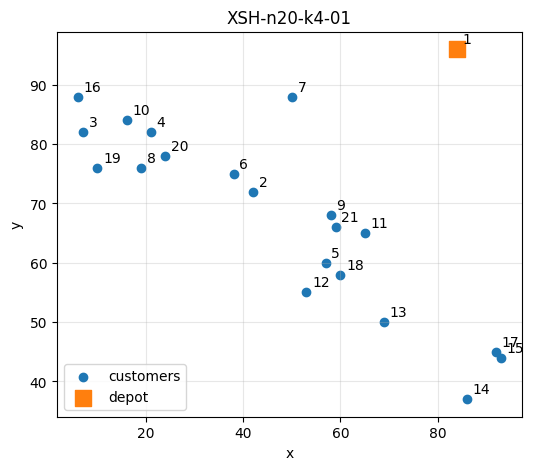

In [14]:
def plot_cvrp_instance(instance):
    depot = instance["depot"]
    fig, ax = plt.subplots(figsize=(6, 5))

    customer_x = [instance["coords"][node][0] for node in instance["customers"]]
    customer_y = [instance["coords"][node][1] for node in instance["customers"]]
    ax.scatter(customer_x, customer_y, label="customers")

    depot_x, depot_y = instance["coords"][depot]
    ax.scatter([depot_x], [depot_y], marker="s", s=120, label="depot")

    for node in instance["nodes"]:
        x_coord, y_coord = instance["coords"][node]
        ax.annotate(str(node), (x_coord, y_coord), xytext=(4, 4), textcoords="offset points")

    ax.set_title(instance["metadata"].get("NAME", instance["path"].stem))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid(True, alpha=0.3)
    return ax


plot_cvrp_instance(cvrp_instance)
plt.show()


## CVRP Formulation

This uses an arc-based CVRP formulation with binary arc variables `x_i_j` and MTZ load variables `u_i`:

- each customer has exactly one incoming and one outgoing arc
- the depot has the selected number of departures and returns
- MTZ load constraints remove customer subtours and enforce capacity
- the objective minimizes total Euclidean route length


In [15]:
def euclidean_distance(a, b):
    return int(round(math.hypot(a[0] - b[0], a[1] - b[1])))


def build_cvrp_model(instance, num_vehicles):
    depot = instance["depot"]
    nodes = instance["nodes"]
    customers = instance["customers"]
    capacity = int(instance["metadata"]["CAPACITY"])
    total_demand = sum(instance["demands"][node] for node in customers)

    if num_vehicles < 1:
        raise ValueError("num_vehicles must be at least 1.")
    if num_vehicles > len(customers):
        raise ValueError("num_vehicles cannot exceed the number of selected customers.")
    if total_demand > capacity * num_vehicles:
        raise ValueError("Selected customers exceed the available vehicle capacity.")

    distances = {
        (i, j): euclidean_distance(instance["coords"][i], instance["coords"][j])
        for i in nodes
        for j in nodes
        if i != j
    }

    model_name = instance["metadata"].get("NAME", instance["path"].stem).replace("-", "_")
    model = Model(name=f"CVRP_{model_name}")

    x = model.binary_var_dict(distances.keys(), name="x")
    u = model.integer_var_dict(customers, lb=0, ub=capacity, name="u")

    model.minimize(model.sum(distances[i, j] * x[i, j] for i, j in distances))

    for customer in customers:
        model.add_constraint(
            model.sum(x[i, customer] for i in nodes if i != customer) == 1,
            ctname=f"visit_in_{customer}",
        )
        model.add_constraint(
            model.sum(x[customer, j] for j in nodes if j != customer) == 1,
            ctname=f"visit_out_{customer}",
        )
        model.add_constraint(u[customer] >= instance["demands"][customer], ctname=f"load_min_{customer}")
        model.add_constraint(u[customer] <= capacity, ctname=f"load_max_{customer}")

    model.add_constraint(model.sum(x[depot, j] for j in customers) == num_vehicles, ctname="depot_departures")
    model.add_constraint(model.sum(x[i, depot] for i in customers) == num_vehicles, ctname="depot_returns")

    for i in customers:
        for j in customers:
            if i == j:
                continue
            model.add_constraint(
                u[i] - u[j] + capacity * x[i, j] <= capacity - instance["demands"][j],
                ctname=f"mtz_{i}_{j}",
            )

    return model, x, u, distances


In [16]:
cvrp_model, x, u, distances = build_cvrp_model(cvrp_instance, num_vehicles=num_vehicles)

print(f"Docplex variables: {cvrp_model.number_of_variables}")
print(f"Docplex constraints: {cvrp_model.number_of_constraints}")
print(cvrp_model.export_as_lp_string())


Docplex variables: 440
Docplex constraints: 462
\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: CVRP_XSH_n20_k4_01

Minimize
 obj: 48 x_1_2 + 78 x_1_3 + 65 x_1_4 + 45 x_1_5 + 51 x_1_6 + 35 x_1_7 + 68 x_1_8
      + 38 x_1_9 + 69 x_1_10 + 36 x_1_11 + 51 x_1_12 + 48 x_1_13 + 59 x_1_14
      + 53 x_1_15 + 78 x_1_16 + 52 x_1_17 + 45 x_1_18 + 77 x_1_19 + 63 x_1_20
      + 39 x_1_21 + 48 x_2_1 + 36 x_2_3 + 23 x_2_4 + 19 x_2_5 + 5 x_2_6
      + 18 x_2_7 + 23 x_2_8 + 16 x_2_9 + 29 x_2_10 + 24 x_2_11 + 20 x_2_12
      + 35 x_2_13 + 56 x_2_14 + 58 x_2_15 + 39 x_2_16 + 57 x_2_17 + 23 x_2_18
      + 32 x_2_19 + 19 x_2_20 + 18 x_2_21 + 78 x_3_1 + 36 x_3_2 + 14 x_3_4
      + 55 x_3_5 + 32 x_3_6 + 43 x_3_7 + 13 x_3_8 + 53 x_3_9 + 9 x_3_10
      + 60 x_3_11 + 53 x_3_12 + 70 x_3_13 + 91 x_3_14 + 94 x_3_15 + 6 x_3_16
      + 93 x_3_17 + 58 x_3_18 + 7 x_3_19 + 17 x_3_20 + 54 x_3_21 + 65 x_4_1
      + 23 x_4_2 + 14 x_4_3 + 42 x_4_5 + 18 x_4_6 + 30 x_4_7 + 6 x_4_8
      + 40 x

## Convert CVRP to QUBO

In [17]:
qp = from_docplex_mp(cvrp_model)
converter = QuadraticProgramToQubo()
qubo = converter.convert(qp)

print("Original QuadraticProgram")
print(f"  variables: {qp.get_num_vars()}")
print(f"  linear constraints: {len(qp.linear_constraints)}")
print()
print("QUBO")
print(f"  variables: {qubo.get_num_vars()}")
print(f"  linear terms: {len(qubo.objective.linear.to_dict())}")
print(f"  quadratic terms: {len(qubo.objective.quadratic.to_dict())}")
print(f"  converter penalty: {converter.penalty}")


Original QuadraticProgram
  variables: 440
  linear constraints: 462

QUBO
  variables: 4320
  linear terms: 4320
  quadratic terms: 106600
  converter penalty: 16695.0


In [18]:
QUBO_LP_PREVIEW_CHARS = 4000
MAX_QUBO_VARS_FOR_LP_PREVIEW = 500

if qubo.get_num_vars() <= MAX_QUBO_VARS_FOR_LP_PREVIEW:
    qubo_lp = qubo.export_as_lp_string()
    print(qubo_lp[:QUBO_LP_PREVIEW_CHARS])

    if len(qubo_lp) > QUBO_LP_PREVIEW_CHARS:
        print(
            f"\n... truncated {len(qubo_lp) - QUBO_LP_PREVIEW_CHARS} characters. "
            "Increase QUBO_LP_PREVIEW_CHARS to show more."
        )
else:
    print(
        f"QUBO has {qubo.get_num_vars()} variables; skipping the LP export preview. "
        "Increase MAX_QUBO_VARS_FOR_LP_PREVIEW if you still want to print it."
    )


QUBO has 4320 variables; skipping the LP export preview. Increase MAX_QUBO_VARS_FOR_LP_PREVIEW if you still want to print it.


## Ising Hamiltonian for VQE

In [19]:
qubitOp, offset = qubo.to_ising()

print("Offset:", offset)
print("Number of qubits:", qubitOp.num_qubits)
print("Number of Pauli terms:", len(qubitOp))

MAX_TERMS_TO_PRINT = 20
for pauli, coeff in zip(qubitOp.paulis[:MAX_TERMS_TO_PRINT], qubitOp.coeffs[:MAX_TERMS_TO_PRINT]):
    print(f"{coeff.real:+.6f} * {pauli}")

if len(qubitOp) > MAX_TERMS_TO_PRINT:
    print(f"... {len(qubitOp) - MAX_TERMS_TO_PRINT} more terms")


KeyboardInterrupt: 

The above code block took    to execute

## Optional VQE Ansatz

Only build a VQE ansatz when the QUBO is small enough for local simulation. If this prints the warning, lower `CUSTOMER_LIMIT` or switch to a decomposition/compression approach before running VQE.


In [ ]:
MAX_QUBITS_FOR_LOCAL_VQE = 20

if qubitOp.num_qubits <= MAX_QUBITS_FOR_LOCAL_VQE:
    from qiskit.circuit.library import real_amplitudes

    ansatz = real_amplitudes(qubitOp.num_qubits, reps=1)
    display(ansatz.decompose().draw("mpl", style="iqp"))
else:
    print(
        f"QUBO has {qubitOp.num_qubits} qubits, which is too large for the "
        "simple local VQE simulator path. Reduce CUSTOMER_LIMIT before running VQE."
    )


## Qubit Comparison Only

The cells below do not solve the CVRP instance. They only estimate binary variables, which are the direct qubit counts for one-binary-variable-to-one-qubit QUBO encodings.

In [ ]:
def bits_for_integer_upper_bound(upper_bound):
    """Return binary variables needed to encode an integer in [0, upper_bound]."""
    upper_bound = int(math.floor(upper_bound))
    if upper_bound <= 0:
        return 0
    return math.ceil(math.log2(upper_bound + 1))


def estimate_arc_mtz_qubits(instance):
    """Estimate QUBO variables for the full directed arc + MTZ CVRP model.

    This mirrors the earlier Docplex model structure but avoids converting the
    full instance into a QUBO. Equalities become penalties and add no variables;
    integer load variables and inequality slacks are binary-expanded.
    """
    capacity = int(instance["metadata"]["CAPACITY"])
    customers = instance["customers"]
    num_customers = len(customers)
    num_nodes = num_customers + 1

    arc_variables = num_nodes * num_customers
    load_variables = num_customers * bits_for_integer_upper_bound(capacity)
    load_slack_variables = sum(
        bits_for_integer_upper_bound(capacity - instance["demands"][customer])
        + bits_for_integer_upper_bound(capacity)
        for customer in customers
    )
    mtz_slack_variables = sum(
        bits_for_integer_upper_bound(2 * capacity - instance["demands"][j])
        for i in customers
        for j in customers
        if i != j
    )

    total = arc_variables + load_variables + load_slack_variables + mtz_slack_variables
    return {
        "arc_variables": arc_variables,
        "load_variables": load_variables,
        "load_slack_variables": load_slack_variables,
        "mtz_slack_variables": mtz_slack_variables,
        "total_qubits": total,
    }


def directed_degree_relaxation_qubits(instance):
    customers = instance["customers"]
    num_nodes = len(customers) + 1
    return num_nodes * len(customers)


def undirected_degree_relaxation_qubits(instance):
    num_nodes = len(instance["customers"]) + 1
    return math.comb(num_nodes, 2)


def customer_vehicle_assignment_qubits(instance, num_vehicles, with_capacity_slack=False):
    capacity = int(instance["metadata"]["CAPACITY"])
    assignment_variables = len(instance["customers"]) * num_vehicles
    slack_variables = num_vehicles * bits_for_integer_upper_bound(capacity) if with_capacity_slack else 0
    return assignment_variables + slack_variables

In [ ]:
def greedy_capacity_clusters(ordered_customers, demands, capacity):
    clusters = []
    current_cluster = []
    current_load = 0

    for customer in ordered_customers:
        demand = demands[customer]
        if current_cluster and current_load + demand > capacity:
            clusters.append(current_cluster)
            current_cluster = []
            current_load = 0
        current_cluster.append(customer)
        current_load += demand

    if current_cluster:
        clusters.append(current_cluster)
    return clusters


def sweep_clusters(instance):
    depot = instance["depot"]
    depot_x, depot_y = instance["coords"][depot]
    ordered = sorted(
        instance["customers"],
        key=lambda node: math.atan2(
            instance["coords"][node][1] - depot_y,
            instance["coords"][node][0] - depot_x,
        ),
    )
    capacity = int(instance["metadata"]["CAPACITY"])
    return greedy_capacity_clusters(ordered, instance["demands"], capacity)


def first_fit_decreasing_clusters(instance):
    capacity = int(instance["metadata"]["CAPACITY"])
    clusters = []
    loads = []

    for customer in sorted(instance["customers"], key=lambda node: instance["demands"][node], reverse=True):
        demand = instance["demands"][customer]
        placed = False
        for index, load in enumerate(loads):
            if load + demand <= capacity:
                clusters[index].append(customer)
                loads[index] += demand
                placed = True
                break
        if not placed:
            clusters.append([customer])
            loads.append(demand)

    return clusters


def route_second_tsp_assignment_qubits(clusters):
    """TSP assignment encoding width for routing each cluster after clustering."""
    per_cluster = [len(cluster) ** 2 for cluster in clusters]
    return {
        "per_cluster": per_cluster,
        "sequential_qubits": max(per_cluster) if per_cluster else 0,
        "combined_qubits": sum(per_cluster),
    }


def cluster_summary(clusters, demands):
    return [
        {
            "size": len(cluster),
            "load": sum(demands[customer] for customer in cluster),
            "customers": cluster,
        }
        for cluster in clusters
    ]

In [ ]:
def count_capacity_feasible_route_columns(instance):
    """Count set-partitioning route columns by capacity-feasible customer subsets.

    This does not optimize route order or route cost. It only counts subsets that
    could become route columns after a route-cost generator is added.
    """
    customers = instance["customers"]
    demands = instance["demands"]
    capacity = int(instance["metadata"]["CAPACITY"])
    counts_by_size = {}

    def visit(index, load, size):
        if index == len(customers):
            if size > 0:
                counts_by_size[size] = counts_by_size.get(size, 0) + 1
            return

        visit(index + 1, load, size)

        customer = customers[index]
        next_load = load + demands[customer]
        if next_load <= capacity:
            visit(index + 1, next_load, size + 1)

    visit(0, 0, 0)
    return counts_by_size

In [ ]:
comparison_instance = read_cvrp_instance(CVRP_DIR / INSTANCE_NAME)
comparison_vehicle_count = parse_vehicle_count(
    comparison_instance,
    default=len(comparison_instance["customers"]),
)
comparison_capacity = int(comparison_instance["metadata"]["CAPACITY"])
comparison_total_demand = sum(comparison_instance["demands"][node] for node in comparison_instance["customers"])

print(f"Instance: {comparison_instance['metadata'].get('NAME', comparison_instance['path'].stem)}")
print(f"Customers: {len(comparison_instance['customers'])}")
print(f"Parsed vehicles: {comparison_vehicle_count}")
print(f"Capacity: {comparison_capacity}")
print(f"Total demand: {comparison_total_demand}")
print(f"Demand / capacity: {comparison_total_demand / comparison_capacity:.2f}")

In [ ]:
sweep_cluster_list = sweep_clusters(comparison_instance)
ffd_cluster_list = first_fit_decreasing_clusters(comparison_instance)

for name, clusters in [
    ("Sweep capacity clusters", sweep_cluster_list),
    ("First-fit decreasing demand clusters", ffd_cluster_list),
]:
    route_qubits = route_second_tsp_assignment_qubits(clusters)
    print(name)
    print(f"  clusters/routes: {len(clusters)}")
    print(f"  loads: {[item['load'] for item in cluster_summary(clusters, comparison_instance['demands'])]}")
    print(f"  sizes: {[item['size'] for item in cluster_summary(clusters, comparison_instance['demands'])]}")
    print(f"  TSP route-second qubits, sequential max: {route_qubits['sequential_qubits']}")
    print(f"  TSP route-second qubits, combined total: {route_qubits['combined_qubits']}")
    print()

In [ ]:
arc_mtz_estimate = estimate_arc_mtz_qubits(comparison_instance)
route_column_counts_by_size = count_capacity_feasible_route_columns(comparison_instance)
all_feasible_route_columns = sum(route_column_counts_by_size.values())

sweep_route_qubits = route_second_tsp_assignment_qubits(sweep_cluster_list)
ffd_route_qubits = route_second_tsp_assignment_qubits(ffd_cluster_list)

comparison_rows = [
    {
        "method": "Full arc-MTZ CVRP QUBO estimate",
        "qubits": arc_mtz_estimate["total_qubits"],
        "quantum_piece": "one full CVRP QUBO",
        "keeps_capacity": "yes",
        "keeps_4_routes": "yes",
        "notes": "estimated only; no full QUBO conversion",
    },
    {
        "method": "Directed degree-only relaxation",
        "qubits": directed_degree_relaxation_qubits(comparison_instance),
        "quantum_piece": "directed arc selection",
        "keeps_capacity": "no",
        "keeps_4_routes": "depot count only",
        "notes": "drops MTZ load and subtour constraints",
    },
    {
        "method": "Undirected degree relaxation",
        "qubits": undirected_degree_relaxation_qubits(comparison_instance),
        "quantum_piece": "undirected edge selection",
        "keeps_capacity": "no",
        "keeps_4_routes": "depot degree only",
        "notes": "2-factor style relaxation; drops direction, capacity, subtours",
    },
    {
        "method": "Customer-to-vehicle assignment, soft capacity",
        "qubits": customer_vehicle_assignment_qubits(comparison_instance, comparison_vehicle_count, with_capacity_slack=False),
        "quantum_piece": "cluster assignment only",
        "keeps_capacity": "soft penalty",
        "keeps_4_routes": "yes",
        "notes": "route order handled after clustering",
    },
    {
        "method": "Customer-to-vehicle assignment + capacity slack",
        "qubits": customer_vehicle_assignment_qubits(comparison_instance, comparison_vehicle_count, with_capacity_slack=True),
        "quantum_piece": "cluster assignment only",
        "keeps_capacity": "yes, encoded slack",
        "keeps_4_routes": "yes",
        "notes": "does not encode route order",
    },
    {
        "method": "Cluster-first sweep, route-second TSP",
        "qubits": sweep_route_qubits["sequential_qubits"],
        "quantum_piece": "largest route TSP subproblem",
        "keeps_capacity": "yes per cluster",
        "keeps_4_routes": "no" if len(sweep_cluster_list) != comparison_vehicle_count else "yes",
        "notes": f"{len(sweep_cluster_list)} route subproblems; combined route QUBO would be {sweep_route_qubits['combined_qubits']} qubits",
    },
    {
        "method": "Cluster-first FFD demand, route-second TSP",
        "qubits": ffd_route_qubits["sequential_qubits"],
        "quantum_piece": "largest route TSP subproblem",
        "keeps_capacity": "yes per cluster",
        "keeps_4_routes": "no" if len(ffd_cluster_list) != comparison_vehicle_count else "yes",
        "notes": f"{len(ffd_cluster_list)} route subproblems; combined route QUBO would be {ffd_route_qubits['combined_qubits']} qubits",
    },
    {
        "method": "Set partitioning, all capacity-feasible columns",
        "qubits": all_feasible_route_columns,
        "quantum_piece": "route-column selection master",
        "keeps_capacity": "yes by columns",
        "keeps_4_routes": "yes as equality penalty",
        "notes": "counts columns only; no route costs optimized here",
    },
]

for cap in [100, 500, 1000]:
    comparison_rows.append(
        {
            "method": f"Set partitioning, capped generated columns ({cap})",
            "qubits": min(cap, all_feasible_route_columns),
            "quantum_piece": "route-column selection master",
            "keeps_capacity": "yes by columns",
            "keeps_4_routes": "yes as equality penalty",
            "notes": "qubits equal retained route columns; coverage depends on generator",
        }
    )

In [ ]:
def print_markdown_table(rows, columns):
    print("| " + " | ".join(columns) + " |")
    print("| " + " | ".join("---" for _ in columns) + " |")
    for row in rows:
        print("| " + " | ".join(str(row[column]) for column in columns) + " |")


columns = ["method", "qubits", "quantum_piece", "keeps_capacity", "keeps_4_routes", "notes"]
print_markdown_table(sorted(comparison_rows, key=lambda row: row["qubits"]), columns)

print("\nFull arc-MTZ estimate breakdown:")
for key, value in arc_mtz_estimate.items():
    print(f"  {key}: {value}")

print("\nSet-partitioning route-column counts by customer subset size:")
for subset_size in sorted(route_column_counts_by_size):
    print(f"  size {subset_size}: {route_column_counts_by_size[subset_size]}")


In [ ]:
plot_rows = sorted(comparison_rows, key=lambda row: row["qubits"])
labels = [row["method"] for row in plot_rows]
values = [row["qubits"] for row in plot_rows]

fig, ax = plt.subplots(figsize=(10, 6))
y_positions = np.arange(len(labels))
ax.barh(y_positions, values, color="tab:blue")
ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Estimated qubits / QUBO binary variables")
ax.set_xscale("log")
ax.set_title("CVRP Qubit Count Comparison")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()